# Lasso Gold Return Prediction

## 1. Setup and Data Loading

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import Lasso
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
TARGET = "tomorrow_gold_log_return"

In [2]:
data = pd.read_csv(
    "daily_commodity_market_data_cleaned.csv",
    index_col=0,
    parse_dates=True,
)

data = data.sort_index()

print("Dataset shape:", data.shape)
print("Start date:", data.index.min())
print("End date:", data.index.max())
print("Missing values:", data.isna().sum().sum())

data.head()

Dataset shape: (5016, 22)
Start date: 2004-01-22 00:00:00
End date: 2026-07-13 00:00:00
Missing values: 0


,tomorrow_gold_log_return,gold_return_1d,gold_return_5d,gold_return_20d,gold_volatility_5d,gold_volatility_20d,gold_close_pos,gold_volume_change,gold_relative_volume,crude_oil_return_1d,...,platinum_return_1d,us_dollar_index_return_1d,sp_500_return_1d,eur_usd_return_1d,vix_change_1d,breakeven_inflation_10y_diff_bps,us_2_year_treasury_yields_diff_bps,us_10_year_treasury_yields_diff_bps,two_ten_slope,two_ten_slope_change_bps
Date,,,,,,,,,,,,,,,,,,,,,
2004-01-22,-0.005135,-0.002679,-0.028137,-0.000975,0.016754,0.010122,0.5,0.000000,0.060060,0.010071,...,0.011614,-0.006273,-0.003212,0.005204,0.37,-3.0,-3.0,-6.0,2.33,-3.0
2004-01-23,-0.003192,-0.005135,-0.001225,-0.003182,0.008370,0.010167,0.5,0.000000,0.069686,0.000286,...,0.002056,0.008586,-0.002091,-0.011224,0.13,4.0,5.0,10.0,2.38,5.0
2004-01-26,0.008327,-0.003192,-0.000246,-0.009790,0.008266,0.010153,0.5,0.000000,0.076336,-0.013543,...,-0.018656,0.007940,0.012034,-0.007584,-0.29,0.0,4.0,7.0,2.41,3.0
2004-01-27,0.010916,0.008327,-0.006564,-0.002436,0.005467,0.010340,0.5,0.000000,0.117302,-0.010206,...,0.010177,-0.011180,-0.009846,0.011859,0.80,0.0,-5.0,-5.0,2.41,0.0
2004-01-28,-0.039365,0.010916,0.008236,0.005322,0.007394,0.010611,0.5,10.146747,19.954106,-0.014763,...,-0.022104,0.007965,-0.013703,-0.015548,1.43,3.0,17.0,11.0,2.35,-6.0


In [3]:
X = data.drop(columns=[TARGET])
y = data[TARGET]

feature_names = X.columns.tolist()

print("Number of predictors:", X.shape[1])
print("Target:", TARGET)

Number of predictors: 21
Target: tomorrow_gold_log_return


## 2. Chronological Train, Validation, and Test Split

### 2.1 Create Chronological Splits

In [4]:
train_end = int(len(data) * 0.70)
validation_end = int(len(data) * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_validation = X.iloc[train_end:validation_end]
y_validation = y.iloc[train_end:validation_end]

X_test = X.iloc[validation_end:]
y_test = y.iloc[validation_end:]

print("Training rows:", len(X_train))
print("Validation rows:", len(X_validation))
print("Test rows:", len(X_test))

Training rows: 3511
Validation rows: 752
Test rows: 753


### 2.2 Verify Date Ranges

In [5]:
split_summary = pd.DataFrame({
    "Split": [
        "Training",
        "Validation",
        "Test"
    ],
    "Rows": [
        len(X_train),
        len(X_validation),
        len(X_test)
    ],
    "Start_Date": [
        X_train.index.min(),
        X_validation.index.min(),
        X_test.index.min()
    ],
    "End_Date": [
        X_train.index.max(),
        X_validation.index.max(),
        X_test.index.max()
    ]
})

split_summary

,Split,Rows,Start_Date,End_Date
0,Training,3511,2004-01-22,2020-07-13
1,Validation,752,2020-07-14,2023-07-10
2,Test,753,2023-07-11,2026-07-13


The dataset was divided chronologically into 70% training, 15% validation, and 15% testing data. A chronological split was used instead of a random split because the observations represent a time series. This prevents future observations from being used to predict earlier periods.

The training set is used to fit the Lasso model. The validation set is used for hyperparameter tuning and model selection. The test set remains untouched until the final model has been selected.

## 3. Feature Scaling


In [6]:
feature_scaler = StandardScaler()

X_train_scaled = feature_scaler.fit_transform(X_train)
X_validation_scaled = feature_scaler.transform(X_validation)
X_test_scaled = feature_scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_validation_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

print(
    "Training feature mean:",
    np.round(X_train_scaled.mean(), 6)
)

print(
    "Training feature standard deviation:",
    np.round(X_train_scaled.std(), 6)
)

Scaled training shape: (3511, 21)
Scaled validation shape: (752, 21)
Scaled test shape: (753, 21)
Training feature mean: -0.0
Training feature standard deviation: 1.0


Lasso regression requires scaled features because its L1 penalty is applied directly to the coefficients. The scaler was fitted only on the training data and then applied to the validation and test sets to prevent data leakage.

## 4. Zero-Return Baseline

In [7]:
zero_validation_predictions = np.zeros(len(y_validation))

zero_mae = mean_absolute_error(
    y_validation,
    zero_validation_predictions
)

zero_mse = mean_squared_error(
    y_validation,
    zero_validation_predictions
)

zero_rmse = np.sqrt(zero_mse)

zero_r2 = r2_score(
    y_validation,
    zero_validation_predictions
)

zero_baseline_metrics = pd.DataFrame({
    "Model": ["Zero-Return Baseline"],
    "MAE": [zero_mae],
    "MSE": [zero_mse],
    "RMSE": [zero_rmse],
    "R2": [zero_r2],
    "Directional_Accuracy": [np.nan]
})

zero_baseline_metrics

,Model,MAE,MSE,RMSE,R2,Directional_Accuracy
0,Zero-Return Baseline,0.007207,0.000098,0.009875,-0.000076,NaN


The zero-return baseline predicts that every next-day gold return will be zero. It provides a simple benchmark that the Lasso model should outperform on the validation set.

## 5. Baseline Lasso Model


In [8]:
baseline_lasso = Lasso(
    alpha=0.0001,
    max_iter=20_000,
    random_state=SEED
)

baseline_lasso.fit(
    X_train_scaled,
    y_train
)

baseline_validation_predictions = baseline_lasso.predict(
    X_validation_scaled
)

print("Baseline alpha:", baseline_lasso.alpha)
print(
    "Non-zero coefficients:",
    np.count_nonzero(baseline_lasso.coef_)
)
print(
    "Zero coefficients:",
    np.sum(baseline_lasso.coef_ == 0)
)

Baseline alpha: 0.0001
Non-zero coefficients: 13
Zero coefficients: 8


## 6. Baseline Lasso Evaluation

In [9]:
baseline_mae = mean_absolute_error(
    y_validation,
    baseline_validation_predictions
)

baseline_mse = mean_squared_error(
    y_validation,
    baseline_validation_predictions
)

baseline_rmse = np.sqrt(baseline_mse)

baseline_r2 = r2_score(
    y_validation,
    baseline_validation_predictions
)

baseline_directional_accuracy = np.mean(
    np.sign(baseline_validation_predictions)
    == np.sign(y_validation.to_numpy())
)

baseline_lasso_metrics = pd.DataFrame({
    "Model": ["Baseline Lasso"],
    "MAE": [baseline_mae],
    "MSE": [baseline_mse],
    "RMSE": [baseline_rmse],
    "R2": [baseline_r2],
    "Directional_Accuracy": [
        baseline_directional_accuracy
    ]
})

pd.concat(
    [
        zero_baseline_metrics,
        baseline_lasso_metrics
    ],
    ignore_index=True
)

,Model,MAE,MSE,RMSE,R2,Directional_Accuracy
0,Zero-Return Baseline,0.007207,0.000098,0.009875,-0.000076,NaN
1,Baseline Lasso,0.007161,0.000096,0.009787,0.017683,0.545213


## 7. Hyperparameter Tuning

In [10]:
alpha_values = np.logspace(-6, -2, 25)

tuning_results = []

for alpha in alpha_values:
    model = Lasso(
        alpha=alpha,
        max_iter=20_000,
        random_state=SEED
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    validation_predictions = model.predict(
        X_validation_scaled
    )

    mae = mean_absolute_error(
        y_validation,
        validation_predictions
    )

    mse = mean_squared_error(
        y_validation,
        validation_predictions
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_validation,
        validation_predictions
    )

    directional_accuracy = np.mean(
        np.sign(validation_predictions)
        == np.sign(y_validation.to_numpy())
    )

    tuning_results.append({
        "Alpha": alpha,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Directional_Accuracy": directional_accuracy,
        "Non_Zero_Coefficients": np.count_nonzero(
            model.coef_
        ),
        "Zero_Coefficients": np.sum(
            model.coef_ == 0
        )
    })

tuning_results_df = pd.DataFrame(
    tuning_results
).sort_values(
    by="MAE"
).reset_index(drop=True)

tuning_results_df.head(10)

,Alpha,MAE,MSE,RMSE,R2,Directional_Accuracy,Non_Zero_Coefficients,Zero_Coefficients
0,0.000215,0.007155,0.000096,0.009791,0.016930,0.543883,6,15
1,0.000147,0.007155,0.000096,0.009787,0.017754,0.545213,9,12
2,0.000100,0.007161,0.000096,0.009787,0.017683,0.545213,13,8
3,0.000316,0.007162,0.000096,0.009805,0.014128,0.538564,6,15
4,0.000068,0.007170,0.000096,0.009790,0.017103,0.545213,16,5
5,0.000046,0.007180,0.000096,0.009796,0.015812,0.534574,17,4
6,0.001000,0.007182,0.000098,0.009880,-0.001135,0.541223,0,21
7,0.001468,0.007182,0.000098,0.009880,-0.001135,0.541223,0,21
8,0.002154,0.007182,0.000098,0.009880,-0.001135,0.541223,0,21
9,0.010000,0.007182,0.000098,0.009880,-0.001135,0.541223,0,21


In [11]:
best_alpha = tuning_results_df.loc[
    0,
    "Alpha"
]

print("Best alpha:", best_alpha)

tuning_results_df.head()

Best alpha: 0.00021544346900318823


,Alpha,MAE,MSE,RMSE,R2,Directional_Accuracy,Non_Zero_Coefficients,Zero_Coefficients
0,0.000215,0.007155,0.000096,0.009791,0.016930,0.543883,6,15
1,0.000147,0.007155,0.000096,0.009787,0.017754,0.545213,9,12
2,0.000100,0.007161,0.000096,0.009787,0.017683,0.545213,13,8
3,0.000316,0.007162,0.000096,0.009805,0.014128,0.538564,6,15
4,0.000068,0.007170,0.000096,0.009790,0.017103,0.545213,16,5


## 8. Tuned Lasso Evaluation

In [12]:
tuned_lasso = Lasso(
    alpha=best_alpha,
    max_iter=20_000,
    random_state=SEED
)

tuned_lasso.fit(
    X_train_scaled,
    y_train
)

tuned_test_predictions = tuned_lasso.predict(
    X_test_scaled
)

tuned_test_mae = mean_absolute_error(
    y_test,
    tuned_test_predictions
)

tuned_test_mse = mean_squared_error(
    y_test,
    tuned_test_predictions
)

tuned_test_rmse = np.sqrt(tuned_test_mse)

tuned_test_r2 = r2_score(
    y_test,
    tuned_test_predictions
)

tuned_test_directional_accuracy = np.mean(
    np.sign(tuned_test_predictions)
    == np.sign(y_test.to_numpy())
)

print("Selected alpha:", best_alpha)
print(
    "Non-zero coefficients:",
    np.count_nonzero(tuned_lasso.coef_)
)
print(
    "Zero coefficients:",
    np.sum(tuned_lasso.coef_ == 0)
)

tuned_lasso_metrics = pd.DataFrame({
    "Model": ["Tuned Lasso"],
    "MAE": [tuned_test_mae],
    "MSE": [tuned_test_mse],
    "RMSE": [tuned_test_rmse],
    "R2": [tuned_test_r2],
    "Directional_Accuracy": [
        tuned_test_directional_accuracy
    ]
})

tuned_lasso_metrics

Selected alpha: 0.00021544346900318823
Non-zero coefficients: 6
Zero coefficients: 15


,Model,MAE,MSE,RMSE,R2,Directional_Accuracy
0,Tuned Lasso,0.009163,0.000174,0.013197,0.000323,0.532537


In [13]:
baseline_test_predictions = baseline_lasso.predict(
    X_test_scaled
)

baseline_test_mae = mean_absolute_error(
    y_test,
    baseline_test_predictions
)

baseline_test_mse = mean_squared_error(
    y_test,
    baseline_test_predictions
)

baseline_test_rmse = np.sqrt(
    baseline_test_mse
)

baseline_test_r2 = r2_score(
    y_test,
    baseline_test_predictions
)

baseline_test_directional_accuracy = np.mean(
    np.sign(baseline_test_predictions)
    == np.sign(y_test.to_numpy())
)

baseline_test_metrics = pd.DataFrame({
    "Model": ["Baseline Lasso"],
    "MAE": [baseline_test_mae],
    "MSE": [baseline_test_mse],
    "RMSE": [baseline_test_rmse],
    "R2": [baseline_test_r2],
    "Directional_Accuracy": [
        baseline_test_directional_accuracy
    ]
})

lasso_test_comparison = pd.concat(
    [
        baseline_test_metrics,
        tuned_lasso_metrics
    ],
    ignore_index=True
)

lasso_test_comparison

,Model,MAE,MSE,RMSE,R2,Directional_Accuracy
0,Baseline Lasso,0.009173,0.000174,0.013195,0.000677,0.516600
1,Tuned Lasso,0.009163,0.000174,0.013197,0.000323,0.532537


## 9. Feature Importance and Feature Selection

In [14]:
lasso_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": tuned_lasso.coef_,
    "Absolute_Coefficient": np.abs(tuned_lasso.coef_)
}).sort_values(
    by="Absolute_Coefficient",
    ascending=False
).reset_index(drop=True)

lasso_feature_importance

,Feature,Coefficient,Absolute_Coefficient
0,us_10_year_treasury_yields_diff_bps,-0.000765,0.000765
1,breakeven_inflation_10y_diff_bps,0.000569,0.000569
2,us_dollar_index_return_1d,-0.000486,0.000486
3,gold_close_pos,-0.000407,0.000407
4,vix_change_1d,-0.000333,0.000333
5,us_2_year_treasury_yields_diff_bps,-0.000225,0.000225
6,gold_volatility_20d,0.000000,0.000000
7,gold_return_20d,-0.000000,0.000000
8,gold_return_5d,-0.000000,0.000000
9,gold_return_1d,-0.000000,0.000000


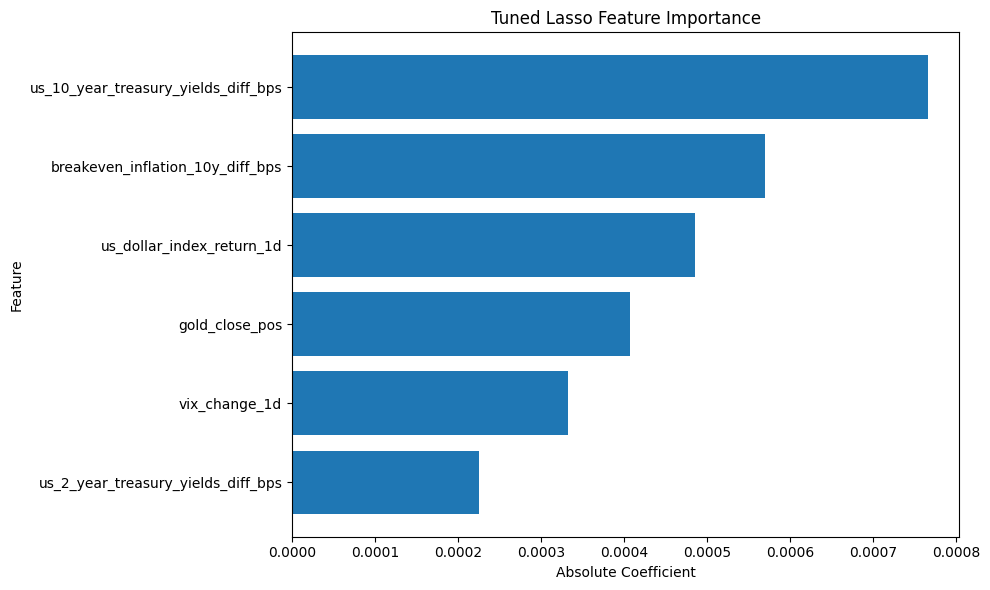

In [15]:
non_zero_features = lasso_feature_importance[
    lasso_feature_importance["Coefficient"] != 0
].copy()

plt.figure(figsize=(10, 6))

plt.barh(
    non_zero_features["Feature"],
    non_zero_features["Absolute_Coefficient"]
)

plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.title("Tuned Lasso Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [16]:
removed_features = lasso_feature_importance[
    lasso_feature_importance["Coefficient"] == 0
]["Feature"].tolist()

print("Selected features:")
for feature in non_zero_features["Feature"]:
    print("-", feature)

print("\nRemoved features:")
for feature in removed_features:
    print("-", feature)

Selected features:
- us_10_year_treasury_yields_diff_bps
- breakeven_inflation_10y_diff_bps
- us_dollar_index_return_1d
- gold_close_pos
- vix_change_1d
- us_2_year_treasury_yields_diff_bps

Removed features:
- gold_volatility_20d
- gold_return_20d
- gold_return_5d
- gold_return_1d
- gold_volatility_5d
- gold_relative_volume
- gold_volume_change
- platinum_return_1d
- copper_return_1d
- silver_return_1d
- crude_oil_return_1d
- sp_500_return_1d
- eur_usd_return_1d
- two_ten_slope
- two_ten_slope_change_bps


The tuned Lasso retained 6 of the original 21 predictors and reduced the remaining 15 coefficients to zero. The largest coefficient by absolute magnitude belonged to the change in the 10-year U.S. Treasury yield, followed by the change in 10-year breakeven inflation and the one-day U.S. dollar index return.

The selected features suggest that interest rates, inflation expectations, the value of the U.S. dollar, market volatility, and gold's position within its daily range contributed more to the model than recent commodity returns, gold return lags, or trading-volume features.

Because the predictors were standardized before training, the absolute coefficient magnitudes can be compared directly. However, these coefficients describe associations within the fitted model and should not be interpreted as proof of causation.

## 10. Export Results

In [17]:
lasso_test_predictions = pd.DataFrame({
    "Date": y_test.index,
    "Actual_Return": y_test.to_numpy(),
    "Baseline_Lasso_Prediction": baseline_test_predictions,
    "Tuned_Lasso_Prediction": tuned_test_predictions
})

lasso_test_predictions.head()

,Date,Actual_Return,Baseline_Lasso_Prediction,Tuned_Lasso_Prediction
0,2023-07-11,0.012810,0.000861,0.000579
1,2023-07-12,0.001532,0.004942,0.003813
2,2023-07-13,0.000459,0.002978,0.002278
3,2023-07-14,-0.003936,-0.002332,-0.001735
4,2023-07-17,0.012622,0.001010,0.000758


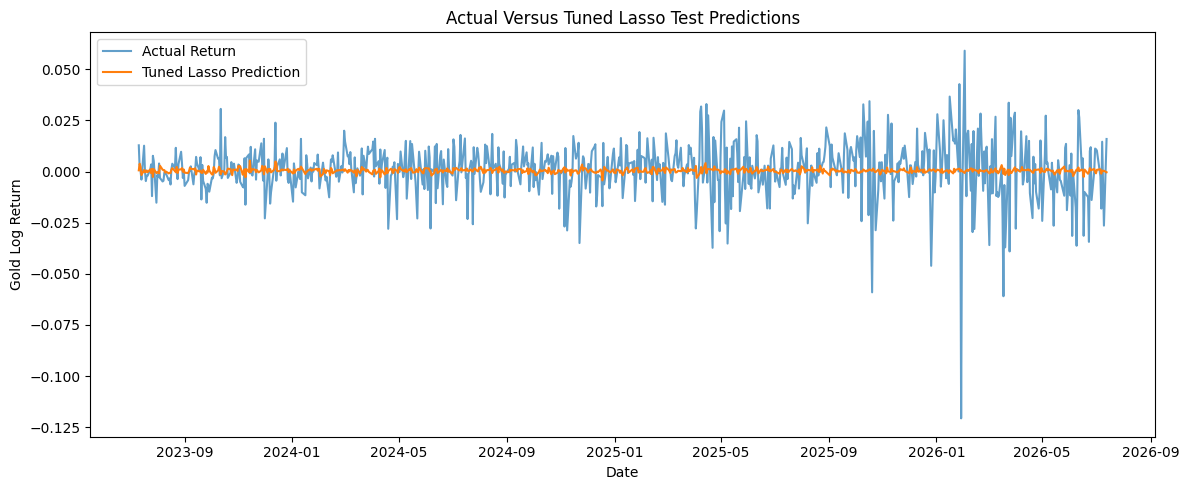

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(
    lasso_test_predictions["Date"],
    lasso_test_predictions["Actual_Return"],
    label="Actual Return",
    alpha=0.7
)

plt.plot(
    lasso_test_predictions["Date"],
    lasso_test_predictions["Tuned_Lasso_Prediction"],
    label="Tuned Lasso Prediction"
)

plt.xlabel("Date")
plt.ylabel("Gold Log Return")
plt.title("Actual Versus Tuned Lasso Test Predictions")
plt.legend()
plt.tight_layout()
plt.show()

The tuned Lasso predictions are concentrated near zero and do not capture the largest positive or negative gold-return movements. This behavior is consistent with the model's near-zero R² and suggests that the selected predictors provide only limited information about next-day return magnitude.

In [19]:
lasso_residuals = (
    lasso_test_predictions["Actual_Return"]
    - lasso_test_predictions["Tuned_Lasso_Prediction"]
)

residual_summary = pd.DataFrame({
    "Actual_Return": lasso_test_predictions["Actual_Return"],
    "Predicted_Return": lasso_test_predictions["Tuned_Lasso_Prediction"],
    "Residual": lasso_residuals
})

residual_summary.describe()

,Actual_Return,Predicted_Return,Residual
count,753.000000,753.000000,753.000000
mean,0.000987,0.000400,0.000587
std,0.013208,0.001035,0.013193
min,-0.120657,-0.004361,-0.121457
25%,-0.004733,-0.000270,-0.005206
50%,0.001489,0.000433,0.000915
75%,0.007958,0.000997,0.007985
max,0.059054,0.005399,0.059759


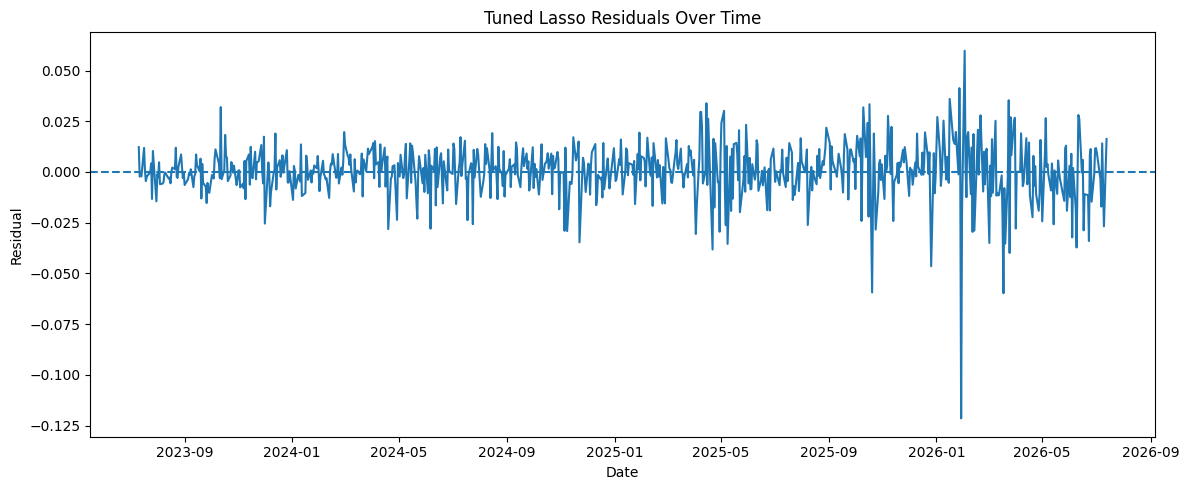

In [20]:
plt.figure(figsize=(12, 5))

plt.plot(
    lasso_test_predictions["Date"],
    lasso_residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Date")
plt.ylabel("Residual")
plt.title("Tuned Lasso Residuals Over Time")
plt.tight_layout()
plt.show()

The residuals are centered near zero but become much larger during periods of extreme market movement. This indicates that the model performs more consistently during ordinary market conditions than during unusually volatile periods.

## 11. Results

In [21]:
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [22]:
lasso_metrics = pd.concat(
    [
        baseline_test_metrics,
        tuned_lasso_metrics
    ],
    ignore_index=True
)

lasso_metrics_path = RESULTS_DIR / "lasso_metrics.csv"
lasso_metrics.to_csv(
    lasso_metrics_path,
    index=False
)

print(f"Saved metrics to: {lasso_metrics_path}")
lasso_metrics

Saved metrics to: results\lasso_metrics.csv


,Model,MAE,MSE,RMSE,R2,Directional_Accuracy
0,Baseline Lasso,0.009173,0.000174,0.013195,0.000677,0.516600
1,Tuned Lasso,0.009163,0.000174,0.013197,0.000323,0.532537


In [23]:
lasso_predictions_path = RESULTS_DIR / "lasso_predictions.csv"

lasso_test_predictions.to_csv(
    lasso_predictions_path,
    index=False
)

print(f"Saved predictions to: {lasso_predictions_path}")
lasso_test_predictions.head()

Saved predictions to: results\lasso_predictions.csv


,Date,Actual_Return,Baseline_Lasso_Prediction,Tuned_Lasso_Prediction
0,2023-07-11,0.012810,0.000861,0.000579
1,2023-07-12,0.001532,0.004942,0.003813
2,2023-07-13,0.000459,0.002978,0.002278
3,2023-07-14,-0.003936,-0.002332,-0.001735
4,2023-07-17,0.012622,0.001010,0.000758


In [24]:
lasso_feature_importance_path = (
    RESULTS_DIR / "lasso_feature_importance.csv"
)

lasso_feature_importance.to_csv(
    lasso_feature_importance_path,
    index=False
)

print(
    "Saved feature importance to:",
    lasso_feature_importance_path
)

lasso_feature_importance.head()

Saved feature importance to: results\lasso_feature_importance.csv


,Feature,Coefficient,Absolute_Coefficient
0,us_10_year_treasury_yields_diff_bps,-0.000765,0.000765
1,breakeven_inflation_10y_diff_bps,0.000569,0.000569
2,us_dollar_index_return_1d,-0.000486,0.000486
3,gold_close_pos,-0.000407,0.000407
4,vix_change_1d,-0.000333,0.000333


## 12. Conclusion

The Lasso regression model was trained to predict the next trading day's gold log return using 21 commodity, financial-market, and macroeconomic predictors.

The baseline Lasso model outperformed the zero-return baseline on the validation set and achieved a directional accuracy of approximately 54.52%. Hyperparameter tuning selected an alpha value of approximately 0.000215. The tuned model reduced the number of non-zero coefficients from 13 to 6, producing a much sparser and more interpretable model.

On the test set, the tuned Lasso achieved:

- MAE: 0.009163
- MSE: 0.000174
- RMSE: 0.013197
- R²: 0.000323
- Directional accuracy: 53.25%

Tuning slightly improved MAE and directional accuracy compared with the baseline Lasso, but RMSE and R² did not improve. Therefore, tuning produced a simpler model without creating a substantial improvement in overall predictive performance.

The most influential retained features were changes in the 10-year U.S. Treasury yield, 10-year breakeven inflation, the U.S. dollar index return, gold's closing position, VIX changes, and changes in the 2-year U.S. Treasury yield. The remaining 15 predictors were reduced to zero, indicating that they contributed little to the tuned linear model.

Overall, Lasso provided useful feature selection and interpretability, but its predictions remained concentrated near zero and explained almost none of the variation in next-day gold returns. The results suggest that the available predictors contain limited linear information about next-day return magnitude, particularly during periods of large market movement.